# Movie Recommendation System - Project Introduction

This project focuses on building a hybrid movie recommendation system using the MovieLens 1M dataset. The objective is to design and compare multiple recommendation approaches — including collaborative filtering, content-based filtering, and neural collaborative filtering — and combine them into a hybrid model for improved recommendation quality.

The system will be evaluated using both regression metrics (RMSE, MAE) and ranking metrics (Precision@K, Recall@K, NDCG) to measure predictive accuracy and recommendation relevance.

---

## Notebook 1 - Data Collection and Preprocessing 

This notebook focuses on preparing the MovieLens dataset for modelling. The key steps include

- Loading ratings, movies and user data
- Inspecting data structure, shape and quality
- Handling data formatting and timestamp conversion
- Checking for missing values and duplicate records
- Analyzing rating distribution, user activity and movie popularity
- Identifying dataset sparsity across the user-item matrix
- Exploring genre distribution and rating over time
- Merging all three datasets into a single master dataframe
- Performing time-based 80/20 train-test split
- Saving processed datasets for downstream modelling

This preprocessing and exploration step ensures clean, structured, and model-ready data while providing key insights into user behavior and movie characteristics that will inform our recommendation algorithms in subsequent phases.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
# load data
ratings = pd.read_csv("OneDrive/Documents/Recommendation System/ratings.csv")
movies = pd.read_csv("OneDrive/Documents/Recommendation System/movies.csv")
users = pd.read_csv("OneDrive/Documents/Recommendation System/users.csv")

print("Ratings shape:", ratings.shape)
print("Movies shape:", movies.shape)
print("Users shape:", users.shape)

Ratings shape: (1000209, 4)
Movies shape: (3883, 3)
Users shape: (6040, 5)


In [3]:
print("--- RATINGS ---")
print(ratings.head())
print("\n--- MOVIES ---")
print(movies.head())
print("\n--- USERS ---")
print(users.head())

--- RATINGS ---
   user_id  movie_id  rating  timestamp
0        1      1193       5  978300760
1        1       661       3  978302109
2        1       914       3  978301968
3        1      3408       4  978300275
4        1      2355       5  978824291

--- MOVIES ---
   movie_id                               title                        genres
0         1                    Toy Story (1995)   Animation|Children's|Comedy
1         2                      Jumanji (1995)  Adventure|Children's|Fantasy
2         3             Grumpier Old Men (1995)                Comedy|Romance
3         4            Waiting to Exhale (1995)                  Comedy|Drama
4         5  Father of the Bride Part II (1995)                        Comedy

--- USERS ---
   user_id gender  age  occupation zip_code
0        1      F    1          10    48067
1        2      M   56          16    70072
2        3      M   25          15    55117
3        4      M   45           7    02460
4        5      M   25   

In [4]:
print("--- RATINGS INFO ---")
print(ratings.info())
print("\n--- MISSING VALUE ---")
print(ratings.isnull().sum())
print(movies.isnull().sum())
print(users.isnull().sum())

--- RATINGS INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000209 entries, 0 to 1000208
Data columns (total 4 columns):
 #   Column     Non-Null Count    Dtype
---  ------     --------------    -----
 0   user_id    1000209 non-null  int64
 1   movie_id   1000209 non-null  int64
 2   rating     1000209 non-null  int64
 3   timestamp  1000209 non-null  int64
dtypes: int64(4)
memory usage: 30.5 MB
None

--- MISSING VALUE ---
user_id      0
movie_id     0
rating       0
timestamp    0
dtype: int64
movie_id    0
title       0
genres      0
dtype: int64
user_id       0
gender        0
age           0
occupation    0
zip_code      0
dtype: int64


In [5]:
# convert timestamp to datetime
ratings['timestamp'] = pd.to_datetime(ratings['timestamp'], unit='s')
print(ratings.head())

   user_id  movie_id  rating           timestamp
0        1      1193       5 2000-12-31 22:12:40
1        1       661       3 2000-12-31 22:35:09
2        1       914       3 2000-12-31 22:32:48
3        1      3408       4 2000-12-31 22:04:35
4        1      2355       5 2001-01-06 23:38:11


In [6]:
# check rating distribution
print("Rating Value Counts:")
print(ratings['rating'].value_counts().sort_index())

print("\nRating Stats:")
print(ratings['rating'].describe())

Rating Value Counts:
rating
1     56174
2    107557
3    261197
4    348971
5    226310
Name: count, dtype: int64

Rating Stats:
count    1.000209e+06
mean     3.581564e+00
std      1.117102e+00
min      1.000000e+00
25%      3.000000e+00
50%      4.000000e+00
75%      4.000000e+00
max      5.000000e+00
Name: rating, dtype: float64


In [7]:
# check duplicates
print("Duplicate ratings:", ratings.duplicated(subset=['user_id', 'movie_id']).sum())

Duplicate ratings: 0


# EDA Visualiations

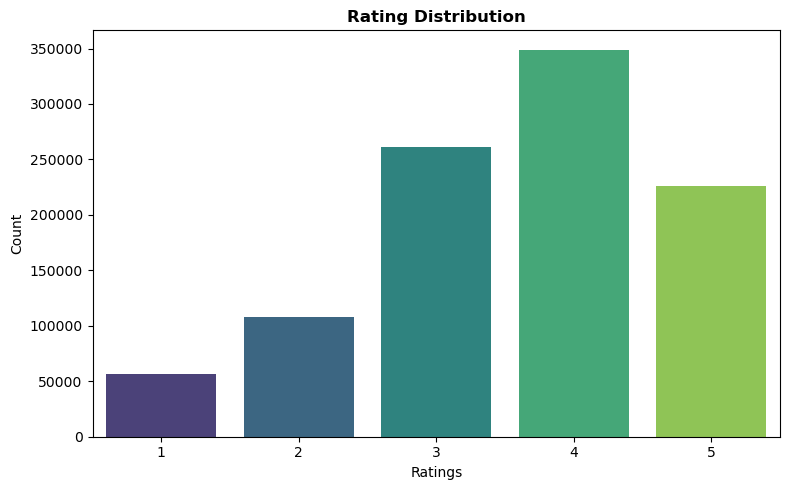

In [10]:
# rating distribution plot
plt.figure(figsize=(8, 5))
sns.countplot(x='rating', data=ratings, palette='viridis')
plt.title('Rating Distribution', fontweight='bold')
plt.xlabel('Ratings')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

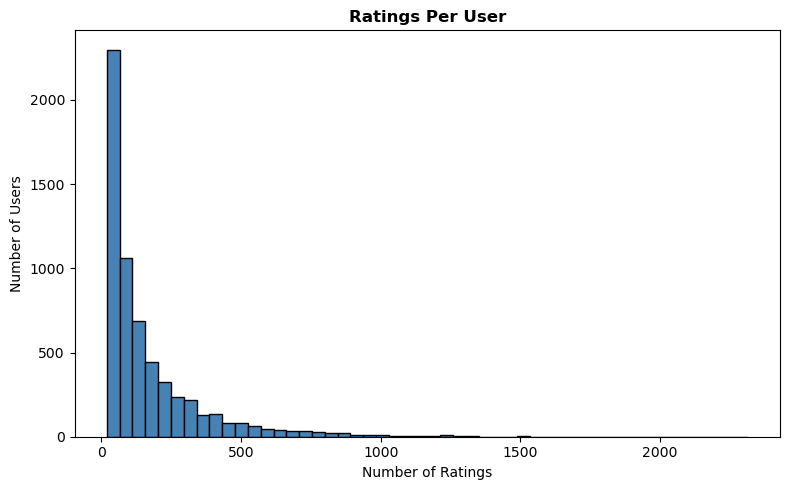

Average ratings per user: 165.6
Min ratings per user: 20
Max ratings per user: 2314


In [20]:
# ratings per users
ratings_per_user = ratings.groupby('user_id')['rating'].count()

plt.figure(figsize=(8, 5))
plt.hist(ratings_per_user, bins=50, color='steelblue', edgecolor='black')
plt.title('Ratings Per User', fontweight='bold')
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Users')
plt.tight_layout()
plt.show()

print("Average ratings per user:", round(ratings_per_user.mean(), 2))
print("Min ratings per user:", ratings_per_user.min())
print("Max ratings per user:", ratings_per_user.max())

Average ratings per movie: 269.89
Min ratings per movie: 1
Max ratings per movie: 3428


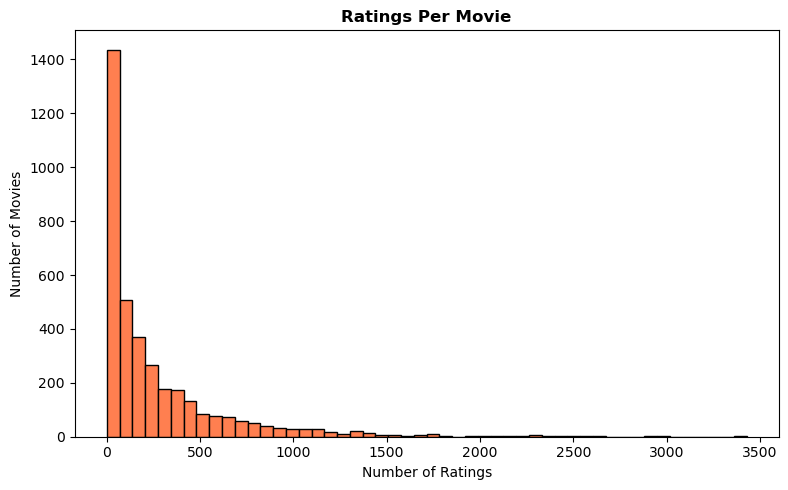

In [19]:
# ratings per movie
ratings_per_movie = ratings.groupby('movie_id')['rating'].count()

plt.figure(figsize=(8, 5))
plt.hist(ratings_per_movie, bins=50, color='coral', edgecolor='black')
plt.title('Ratings Per Movie', fontweight='bold')
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Movies')
plt.tight_layout()
plt.show

print("Average ratings per movie:", round(ratings_per_movie.mean(), 2))
print("Min ratings per movie:", ratings_per_movie.min())
print("Max ratings per movie:", ratings_per_movie.max())

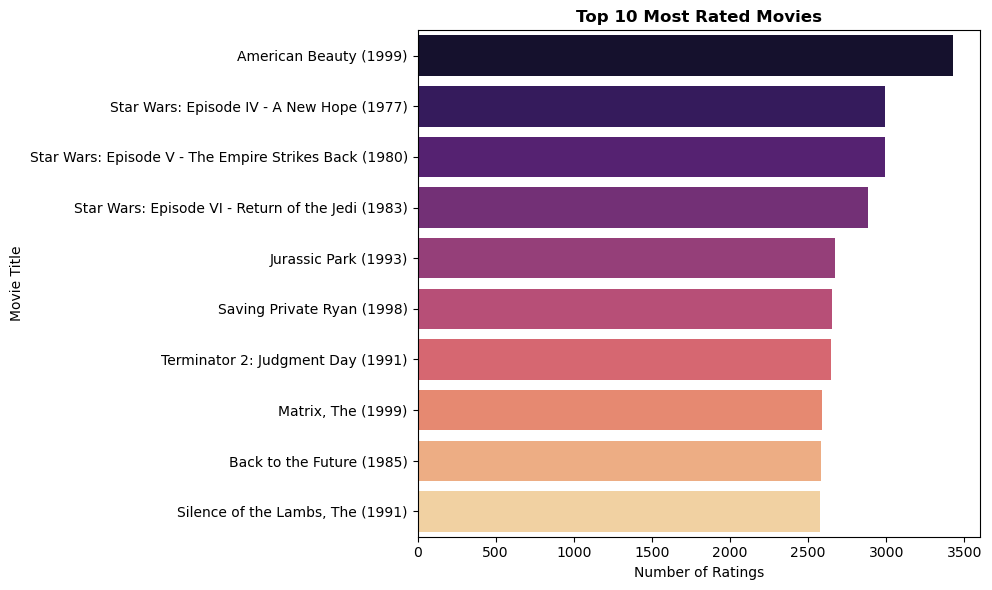

In [24]:
# top 10 most rated movies
top_movies = ratings.groupby('movie_id')['rating'].count().reset_index()
top_movies.columns = ['movie_id', 'rating_count']
top_movies = top_movies.merge(movies[['movie_id', 'title']], on='movie_id')
top_movies = top_movies.sort_values('rating_count', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='rating_count', y='title', data=top_movies, palette='magma')
plt.title('Top 10 Most Rated Movies', fontweight='bold')
plt.xlabel('Number of Ratings')
plt.ylabel('Movie Title')
plt.tight_layout()
plt.show()

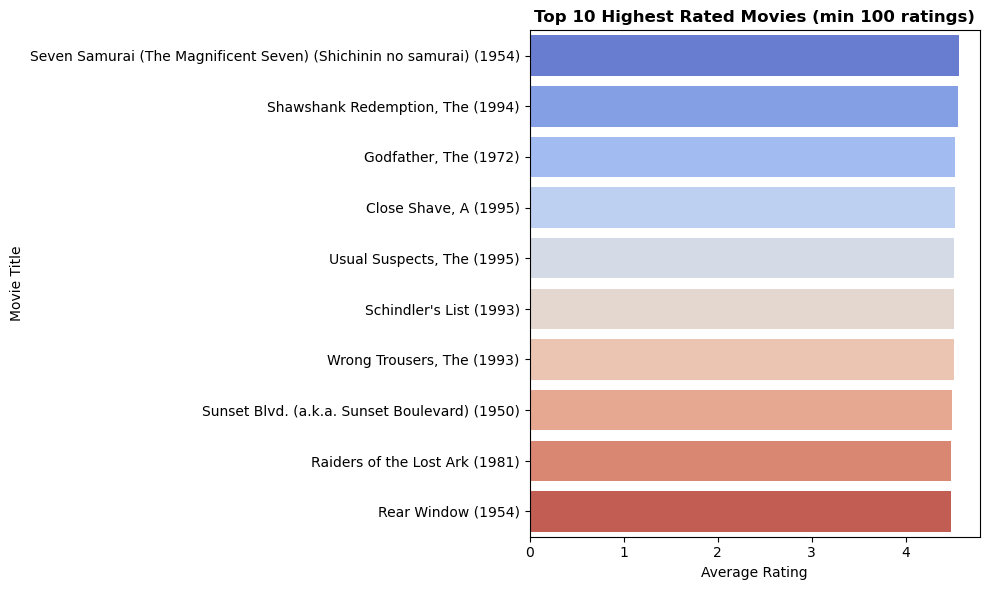

In [26]:
# top 10 highest rated movies(min 100 ratings)
avg_ratings = ratings.groupby('movie_id').agg(
    avg_rating=('rating', 'mean'),
    rating_count=('rating', 'count')
).reset_index()

avg_ratings = avg_ratings[avg_ratings['rating_count'] >= 100]
avg_ratings = avg_ratings.merge(movies[['movie_id', 'title']], on='movie_id')
avg_ratings = avg_ratings.sort_values('avg_rating', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='avg_rating', y='title', data=avg_ratings, palette='coolwarm')
plt.title('Top 10 Highest Rated Movies (min 100 ratings)', fontweight='bold')
plt.xlabel('Average Rating')
plt.ylabel('Movie Title')
plt.tight_layout()
plt.show()

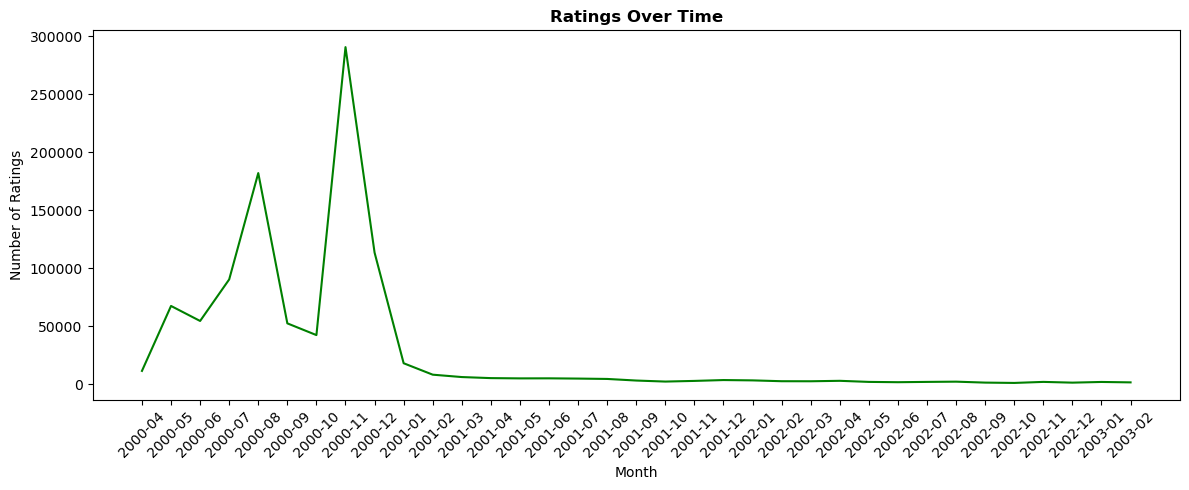

In [28]:
# ratings over time
# grouping rating by month to see when users were most active
ratings['year_month'] = ratings['timestamp'].dt.to_period('M')
ratings_over_time = ratings.groupby('year_month')['rating'].count().reset_index()
ratings_over_time['year_month'] = ratings_over_time['year_month'].astype(str)

plt.figure(figsize=(12, 5))
plt.plot(ratings_over_time['year_month'], ratings_over_time['rating'], color='green')
plt.title('Ratings Over Time', fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Ratings')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [29]:
# sparsity analysis
# it measures how empty the user-matrix is.
# if a user rated only 50 out of 3883 movies, most of the matrix is empty.
# high sparsity(usually above 95%) is normal and expected

n_users = ratings['user_id'].nunique()
n_movies = ratings['movie_id'].nunique()
n_ratings = len(ratings)

sparsity = 1 - (n_ratings / (n_users * n_movies))
print(f"Number of users: {n_users}")
print(f"Number of movies: {n_movies}")
print(f"Number of ratings: {n_ratings}")
print(f"Matrix sparsity: {sparsity:.4%}")

Number of users: 6040
Number of movies: 3706
Number of ratings: 1000209
Matrix sparsity: 95.5316%


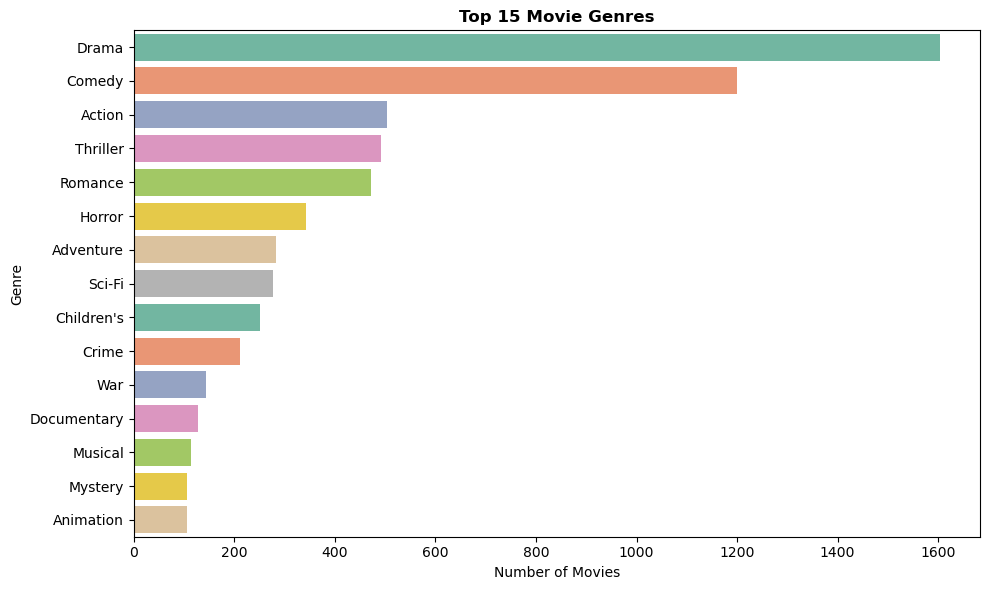

In [31]:
# genre distribution
genres_split = movies['genres'].str.split('|').explode()
genre_counts = genres_split.value_counts().head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='Set2')
plt.title('Top 15 Movie Genres', fontweight='bold')
plt.xlabel('Number of Movies')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

## Merging Table and Train/Test Split by Time

In [32]:
# merge tables
df = ratings.merge(movies, on='movie_id').merge(users, on='user_id')
print("Merged dataframe shape:", df.shape)
print(df.head())

Merged dataframe shape: (1000209, 11)
   user_id  movie_id  rating           timestamp year_month  \
0        1      1193       5 2000-12-31 22:12:40    2000-12   
1        1       661       3 2000-12-31 22:35:09    2000-12   
2        1       914       3 2000-12-31 22:32:48    2000-12   
3        1      3408       4 2000-12-31 22:04:35    2000-12   
4        1      2355       5 2001-01-06 23:38:11    2001-01   

                                    title                        genres  \
0  One Flew Over the Cuckoo's Nest (1975)                         Drama   
1        James and the Giant Peach (1996)  Animation|Children's|Musical   
2                     My Fair Lady (1964)               Musical|Romance   
3                  Erin Brockovich (2000)                         Drama   
4                    Bug's Life, A (1998)   Animation|Children's|Comedy   

  gender  age  occupation zip_code  
0      F    1          10    48067  
1      F    1          10    48067  
2      F    1        

In [33]:
# train/test split by time 
# we split by time rather than randomly in recommendation system
# we will train on past data and test on future interaction
# sort by timestamp
df = df.sort_values('timestamp')

# use last 20% of interactions as test set
split_idx = int(len(df) * 0.8)
train = df.iloc[:split_idx]
test = df.iloc[split_idx:]

print("Train size:", train.shape)
print("Test size:", test.shape)
print("Train date range:", train['timestamp'].min(), "to", train['timestamp'].max())
print("Test date range:", test['timestamp'].min(), "to", test['timestamp'].max())

Train size: (800167, 11)
Test size: (200042, 11)
Train date range: 2000-04-25 23:05:32 to 2000-12-02 14:52:18
Test date range: 2000-12-02 14:52:18 to 2003-02-28 17:49:50


In [34]:
# saving results and files

train.to_csv("OneDrive/Documents/Recommendation System/train.csv", index=False)
test.to_csv("OneDrive/Documents/Recommendation System/test.csv", index=False)
df.to_csv("OneDrive/Documents/Recommendation System/df_clean.csv", index=False)

print("All files saved successfully!")

All files saved successfully!
